# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
# Load the data
import pandas as pd

df = pd.read_csv('loan_data.csv')

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


In [3]:
print(df.columns.tolist())
print(df.dtypes)

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
person_age                          int64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                      float64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object


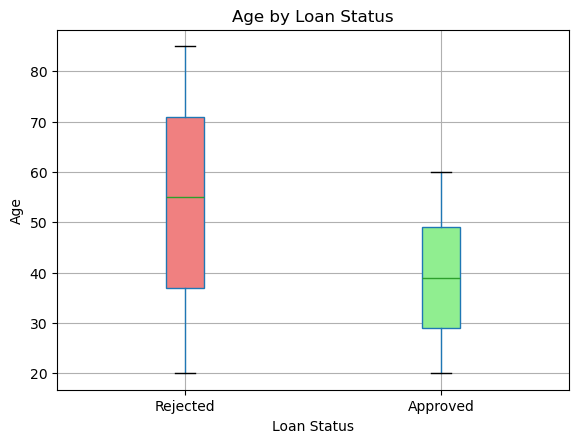

In [9]:
import matplotlib.pyplot as plt

# Create age boxplot by loan status
box = df.boxplot(
    column='person_age',
    by='loan_status',
    patch_artist=True,
    return_type='dict'
)

# Add colors to make the groups easier to read
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['person_age']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Age by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Age')
# Rename 0 and 1 to make the graph easier to read
plt.xticks([1, 2], ['Rejected', 'Approved'])
plt.show()

In [5]:
age_means = df.groupby('loan_status')['person_age'].mean()

print(age_means)

loan_status
0    54.021318
1    39.482117
Name: person_age, dtype: float64


In [ ]:
Rejected applicants were older on average at 54 years old, while approved applicants averaged about 39.5 years old. 
This shows that age may have a noticeable relationship with loan approval.

In [12]:
# Calculate loan approval rate by gender
gender_approval = df.groupby('person_gender')['loan_status'].mean()

print(gender_approval)

person_gender
female    0.110280
male      0.107711
Name: loan_status, dtype: float64


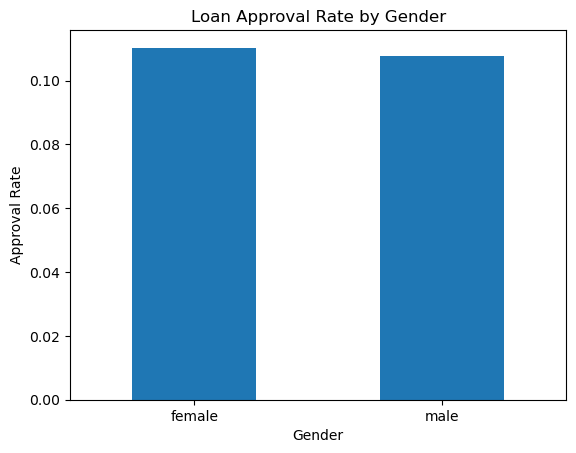

In [11]:
# Visualize approval rate by gender
gender_approval.plot(kind='bar')

plt.title('Loan Approval Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.show()

In [ ]:
Gender does not have much of a relationship with loan approval.
Female applicants had an approval rate of about 11.0%, while male applicants had an approval rate of 10.8%. 
Since the difference is very small, gender does not seem to be a major factor in loan decisions.

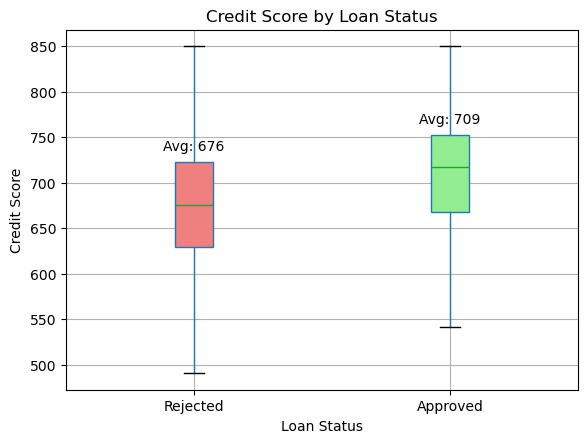

In [15]:
# Create credit score boxplot by loan status
box = df.boxplot(
    column='credit_score',
    by='loan_status',
    patch_artist=True,
    return_type='dict',
    showfliers=False
)

# Add colors
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['credit_score']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Credit Score by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.xticks([1, 2], ['Rejected', 'Approved'])

# Add average credit scores above each box
plt.text(1, 735, 'Avg: 676', ha='center')
plt.text(2, 765, 'Avg: 709', ha='center')

plt.show()

In [20]:
credit_score_means = df.groupby('loan_status')['credit_score'].mean()

credit_score_means.index = ['Rejected', 'Approved']

print(credit_score_means)

Rejected    676.202446
Approved    709.749597
Name: credit_score, dtype: float64


In [ ]:
Credit score appears to have a noticeable relationship with loan approval. 
Approved applicants had an average credit score of about 709, while rejected applicants averaged about 676. 
The boxplot also shows that approved applicants generally had higher credit scores.

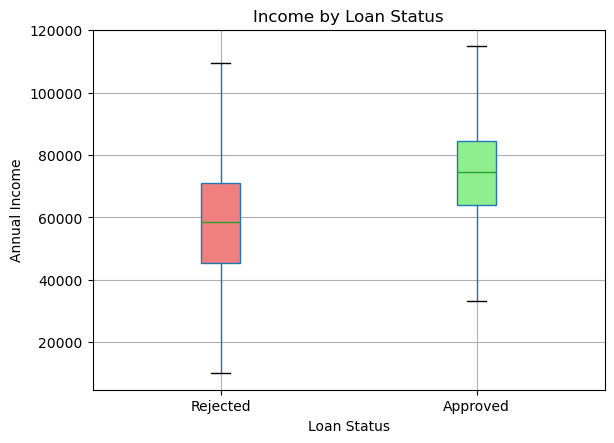

In [16]:
# Create income boxplot by loan status
box = df.boxplot(
    column='person_income',
    by='loan_status',
    patch_artist=True,
    return_type='dict',
    showfliers=False
)

# Add colors
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['person_income']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Income by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income')
plt.xticks([1, 2], ['Rejected', 'Approved'])

plt.show()

In [19]:
income_means = df.groupby('loan_status')['person_income'].mean()

income_means.index = ['Rejected', 'Approved']

print(income_means)

Rejected    58528.531356
Approved    73514.758800
Name: person_income, dtype: float64


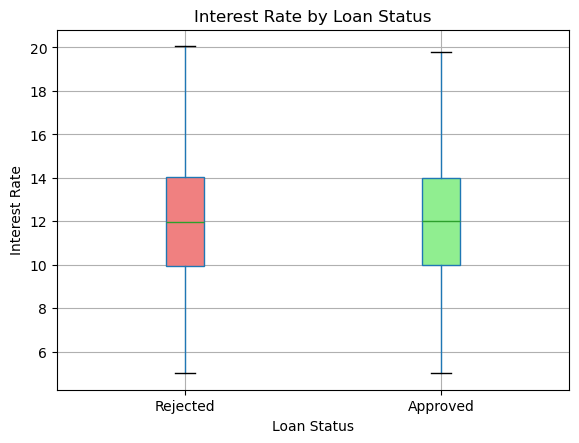

In [21]:
# Create interest rate boxplot by loan status
box = df.boxplot(
    column='loan_int_rate',
    by='loan_status',
    patch_artist=True,
    return_type='dict',
    showfliers=False
)

# Add colors
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['loan_int_rate']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Interest Rate by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate')
plt.xticks([1, 2], ['Rejected', 'Approved'])

plt.show()

In [22]:
interest_means = df.groupby('loan_status')['loan_int_rate'].mean()

interest_means.index = ['Rejected', 'Approved']

print(interest_means)

Rejected    12.002137
Approved    12.009495
Name: loan_int_rate, dtype: float64


In [ ]:
Interest rate has little to do with loan approval. 
Rejected applicants had an average interest rate of about 12.00%, while approved applicants averaged about 12.01%. 
The boxplots also look almost identical, so interest rate does not seem to be a major factor in the approval decision.

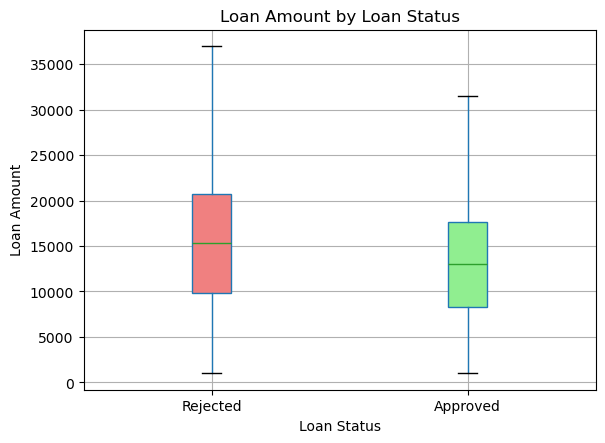

In [23]:
# Create loan amount boxplot by loan status
box = df.boxplot(
    column='loan_amnt',
    by='loan_status',
    patch_artist=True,
    return_type='dict',
    showfliers=False
)

# Add colors
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['loan_amnt']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Loan Amount by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.xticks([1, 2], ['Rejected', 'Approved'])

plt.show()

In [24]:
loan_amount_means = df.groupby('loan_status')['loan_amnt'].mean()

loan_amount_means.index = ['Rejected', 'Approved']

print(loan_amount_means)

Rejected    15386.228851
Approved    13027.322609
Name: loan_amnt, dtype: float64


In [ ]:
Loan amount appears to have some relationship with approval. 
Rejected applicants requested about $15,386 on average, while approved applicants requested about $13,027. 
The difference is noticeable, but the two groups still overlap a lot.

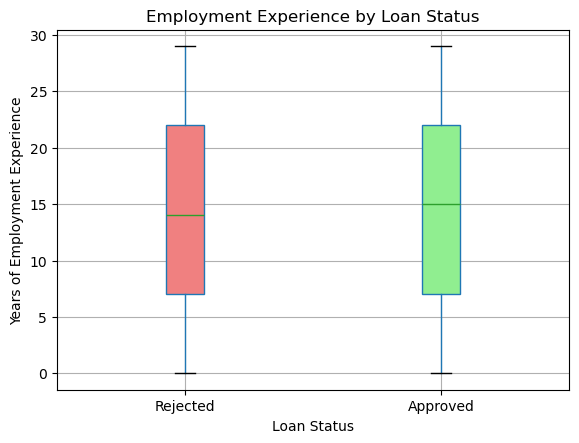

In [25]:
# Create employment experience boxplot by loan status
box = df.boxplot(
    column='person_emp_exp',
    by='loan_status',
    patch_artist=True,
    return_type='dict',
    showfliers=False
)

# Add colors
colors = ['lightcoral', 'lightgreen']

for patch, color in zip(box['person_emp_exp']['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Employment Experience by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Years of Employment Experience')
plt.xticks([1, 2], ['Rejected', 'Approved'])

plt.show()

In [26]:
employment_means = df.groupby('loan_status')['person_emp_exp'].mean()

employment_means.index = ['Rejected', 'Approved']

print(employment_means)

Rejected    14.440771
Approved    14.649499
Name: person_emp_exp, dtype: float64


In [ ]:
Employment experience does not appear to have much of a relationship with loan approval. 
Rejected applicants averaged 14.4 years of experience, while approved applicants averaged 14.6 years. 
The boxplots are very similar, so employment experience does not seem to be a major factor.

In [ ]:
Final Analysis:
    
The features most closely related to loan approval are age, credit score, income, and loan amount. 
Approved applicants were younger on average, had higher credit scores, had higher incomes, and requested somewhat smaller loans.
Gender, interest rate, and employment experience seem to have very little relationship with loan approval because the approved and rejected groups had almost the same values.
The financial institution should probably look more closely at age because there was a noticeable difference between approved and rejected applicants. 
Rejected applicants averaged about 54 years old, while approved applicants averaged about 39.5 years old. This does not prove the model is discriminating based on age, but it could be a concern that should be investigated.
Gender does not appear to be a major concern based on this dataset. 
Female applicants had an approval rate of about 11.0%, while male applicants had an approval rate of about 10.8%, which is almost the same.